# EEGImageNetDataset usage examples

In [1]:
from torch.utils.data import DataLoader
from src.dataset import EEGImageNetDataset
from src.utilities import Args, get_device

In [2]:
args = Args()
device = get_device()

# 1) Recommended: explicit constructor
data = EEGImageNetDataset.from_args(args, map_location=device)

print("dataset size:", len(data))
x, y = data[0]
print("one sample eeg shape:", tuple(x.shape), "label:", y)

loader = DataLoader(data, batch_size=8, shuffle=True)
batch_x, batch_y = next(iter(loader))
print("batch eeg shape:", tuple(batch_x.shape), "batch label shape:", tuple(batch_y.shape))

dataset size: 2000
one sample eeg shape: (62, 400) label: 57
batch eeg shape: (8, 62, 400) batch label shape: (8,)


In [3]:
# Label map from image to index, there are 80 categories in total with 40 coarse categories and 40 fine categories.
data.label_to_index

{'n07758680': 0,
 'n07749192': 1,
 'n12144580': 2,
 'n07740461': 3,
 'n07753275': 4,
 'n07772935': 5,
 'n07756951': 6,
 'n07745940': 7,
 'n02701002': 8,
 'n02901620': 9,
 'n04465666': 10,
 'n03790512': 11,
 'n03845190': 12,
 'n03690473': 13,
 'n03384352': 14,
 'n04389033': 15,
 'n02107142': 16,
 'n02099601': 17,
 'n02112826': 18,
 'n02110185': 19,
 'n02106166': 20,
 'n02106550': 21,
 'n02099712': 22,
 'n02111889': 23,
 'n02992211': 24,
 'n03838899': 25,
 'n03372029': 26,
 'n04487394': 27,
 'n03884397': 28,
 'n04249415': 29,
 'n03495258': 30,
 'n02672831': 31,
 'n02643566': 32,
 'n01443537': 33,
 'n01456756': 34,
 'n01494475': 35,
 'n01496331': 36,
 'n02655020': 37,
 'n01484850': 38,
 'n02630281': 39,
 'n03590841': 40,
 'n02124075': 41,
 'n11939491': 42,
 'n04120489': 43,
 'n03982430': 44,
 'n03877472': 45,
 'n03445777': 46,
 'n03792972': 47,
 'n02992529': 48,
 'n03100240': 49,
 'n03272010': 50,
 'n03888257': 51,
 'n07753592': 52,
 'n02281787': 53,
 'n04044716': 54,
 'n02906734': 55,
 '

## Filter by subject and granularity

### filter by granularity

In [4]:
granularity_filter_data = EEGImageNetDataset(
    dataset_dir="data",
    subject=-1,         # -1 means all subjects
    granularity="fine", # or "coarse", "all"
    eeg_window=(40, 440),
)

print("fine dataset size:", len(granularity_filter_data))

fine dataset size: 32000


### filter by subject

In [5]:
subject_filter_data = EEGImageNetDataset(
    dataset_dir="data",
    subject=1,         # -1 means all subjects
    granularity="all", # or "coarse", "fine"
    eeg_window=(40, 440),
)

print("subject 1 dataset size:", len(subject_filter_data))

subject 1 dataset size: 4000


## EEG visualization example

In [6]:
x.shape

torch.Size([62, 400])

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load channel names
with open("data/mode/montage_ch_names.json") as f:
    all_ch_names = json.load(f)
ch_names = all_ch_names[:62]  # first 62 are EEG electrodes

# Pick any sample index
sample_idx = 0
feat, label = data[sample_idx]  # feat shape: (channels, timesteps)

eeg = feat.detach().cpu().numpy() if hasattr(feat, "detach") else np.asarray(feat)
channels, timesteps = eeg.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Heatmap
im = axes[0].imshow(eeg, aspect="auto", cmap="RdBu_r", origin="lower")
axes[0].set_title(f"EEG Heatmap | sample={sample_idx}, label={label}")
axes[0].set_xlabel("Time (sample)")
axes[0].set_ylabel("Channel")
step = max(1, channels // 10)
axes[0].set_yticks(range(0, channels, step))
axes[0].set_yticklabels(ch_names[::step])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# 2) Stacked channel traces
scale = np.std(eeg) * 2.0 if np.std(eeg) > 0 else 1.0
time = np.arange(timesteps)
offsets = np.arange(channels) * scale
axes[1].plot(time, (eeg + offsets[:, None]).T, linewidth=0.7)
axes[1].set_title("EEG Channel Traces (stacked)")
axes[1].set_xlabel("Time (sample)")
axes[1].set_ylabel("Channel")
axes[1].set_yticks(offsets[::step])
axes[1].set_yticklabels(ch_names[::step])

plt.tight_layout()
plt.show()

print("eeg shape:", eeg.shape, "label:", label)

## EEG Features Visualization

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import mne

# Load channel names & montage
with open("data/mode/montage_ch_names.json") as f:
    ch_names = json.load(f)[:62]

montage = mne.channels.read_dig_fif("data/mode/montage.fif")
with open("data/mode/montage_ch_names.json") as f:
    montage.ch_names = json.load(f)

sfreq = 1000  # Hz
tmin = 0.040  # EEG window start in seconds

# Collect multiple trials for the same label
target_label = data[0][1]
trials = []
for i in range(len(data)):
    x_i, y_i = data[i]
    if y_i == target_label:
        arr = x_i.detach().cpu().numpy() if hasattr(x_i, "detach") else np.asarray(x_i)
        trials.append(arr)
    if len(trials) >= 50:
        break

trials = np.stack(trials)  # (n_trials, 62, timesteps)

# Build MNE objects
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
info.set_montage(montage)

epochs = mne.EpochsArray(trials, info, tmin=tmin)
evoked = epochs.average()

print(f"Collected {len(trials)} trials for label={target_label}")
print(epochs)

Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated
Collected 50 trials for label=57
<EpochsArray | 50 events (all good), 0.04 – 0.439 s (baseline off), ~9.5 MiB, data loaded,
 '1': 50>


/var/folders/53/x49yqccd0r78tkl0172f7dbr0000gn/T/ipykernel_15731/3308538409.py:10: RuntimeWarning: This filename (data/mode/montage.fif) does not conform to MNE naming conventions. All montage files should end with -dig.fif or -dig.fif.gz
  montage = mne.channels.read_dig_fif("data/mode/montage.fif")


### 1. Time-domain: Event-Related Potentials (ERPs)
Average voltage across trials for selected channels, showing characteristic peaks (P1, N1, P2, P3) associated with visual processing stages.

No projector specified for this dataset. Please consider the method self.add_proj.


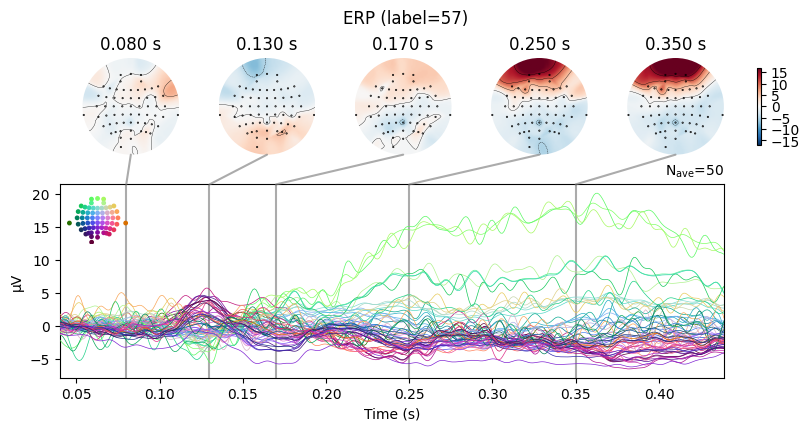

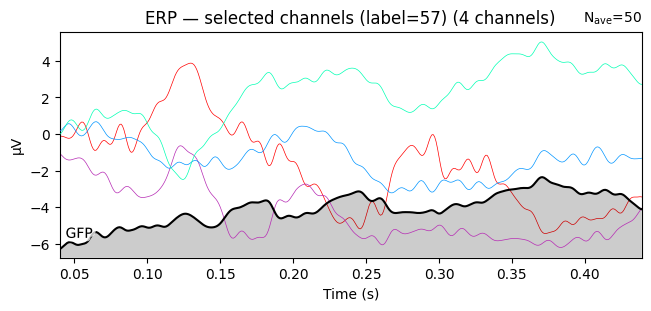

In [ ]:
# 1a) ERP butterfly plot + topomaps at key latencies
fig = evoked.plot_joint(
    times=[0.08, 0.13, 0.17, 0.25, 0.35],  # P1, C1, N170, P2, P3
    title=f"ERP (label={target_label})",
    show=False,
)
plt.show()

# 1b) ERP by channel with confidence band
fig = evoked.plot(
    picks=["OZ", "PZ", "CZ", "FZ"],
    spatial_colors=True,
    gfp=True,
    titles=dict(eeg=f"ERP — selected channels (label={target_label})"),
    show=False,
)
plt.show()

### 2. Frequency-domain: Power Spectral Density (PSD) & Band Power
PSD shows how much power exists at each frequency. Band-specific power aggregates this across standard EEG bands (delta, theta, alpha, beta, gamma).

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


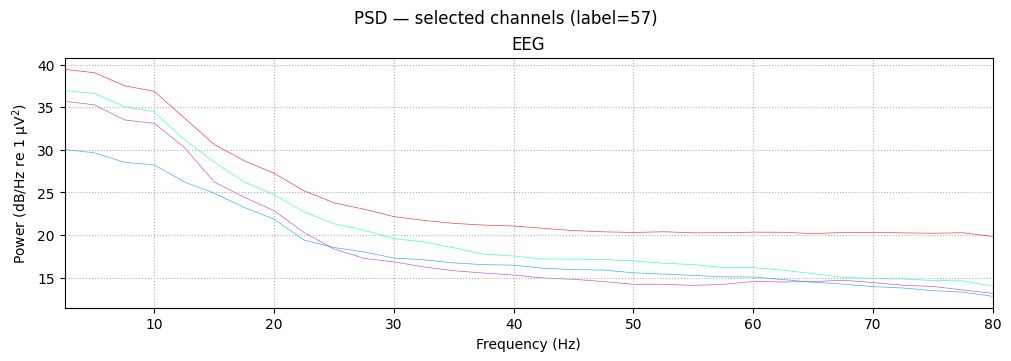

Averaging across epochs before plotting...


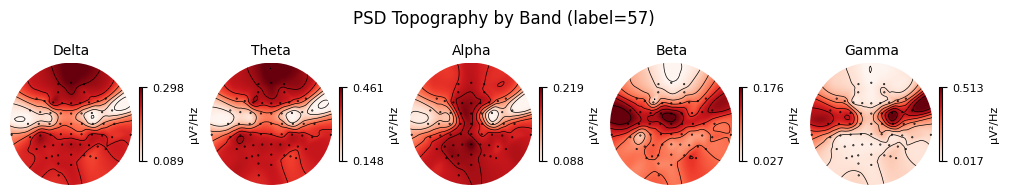

In [ ]:
# 2a) PSD using MNE's compute_psd (multitaper)
spectrum = epochs.compute_psd(method="multitaper", fmin=0.5, fmax=80)

fig = spectrum.plot(picks=["OZ", "PZ", "CZ", "FZ"], show=False)
fig.suptitle(f"PSD — selected channels (label={target_label})")
plt.show()

# 2b) PSD topography per frequency band
fig = spectrum.plot_topomap(
    bands=dict(
        Delta=(0.5, 4),
        Theta=(4, 8),
        Alpha=(8, 13),
        Beta=(13, 30),
        Gamma=(30, 80),
    ),
    normalize=True,
    show=False,
)
fig.suptitle(f"PSD Topography by Band (label={target_label})", y=1.2)
plt.show()

### 3. Time-frequency: Spectrogram & ERSP
Spectrograms show how frequency content changes over time. ERSP (Event-Related Spectral Perturbation) reveals how oscillatory power is modulated relative to baseline.

/var/folders/53/x49yqccd0r78tkl0172f7dbr0000gn/T/ipykernel_15731/2683256919.py:10: UserWarning: At least one of the wavelets (401) is longer than the signal (400). Consider using a longer signal or shorter wavelets.
  tfr = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=n_cycles, average=True)


Applying baseline correction (mode: percent)


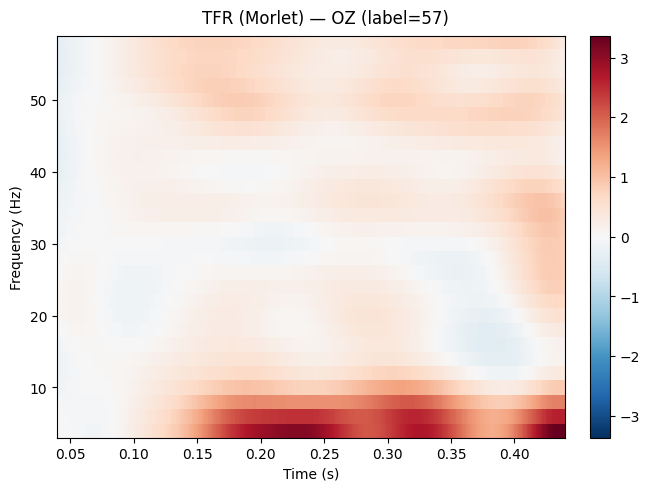

Applying baseline correction (mode: percent)


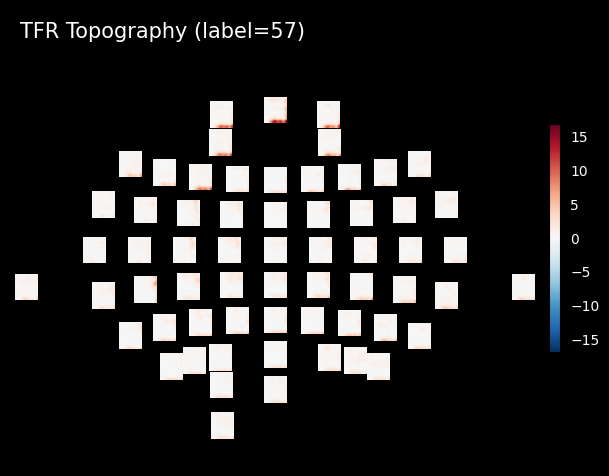

In [ ]:
# 3a) Time-frequency representation (Morlet wavelets)
freqs = np.arange(4, 60, 2)
# MNE wavelet length = 2*int(n_cycles*sfreq/(2π*freq)*5)+1, must be ≤ 400
# => n_cycles < 200 * 2π * freq / (5 * sfreq)
n_samples = 400
max_cycles = (n_samples // 2) * 2 * np.pi * freqs / (5 * sfreq)
n_cycles = np.minimum(freqs / 2, max_cycles)
n_cycles = np.maximum(n_cycles, 0.5)

tfr = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=n_cycles, average=True)

# Single-channel TFR
fig = tfr.plot(picks=["OZ"], baseline=(0.04, 0.1), mode="percent", show=False,
               title=f"TFR (Morlet) — OZ (label={target_label})")
plt.show()

# 3b) TFR topomaps at selected time points
fig = tfr.plot_topo(
    baseline=(0.04, 0.1), mode="percent", show=False,
    title=f"TFR Topography (label={target_label})",
)
plt.show()

### 4. Connectivity: Functional Connectivity Matrix
Correlation between channels across time, showing how different brain regions co-activate during visual processing.

/var/folders/53/x49yqccd0r78tkl0172f7dbr0000gn/T/ipykernel_15731/1629546460.py:5: RuntimeWarning: There were no Annotations stored in <EpochsArray | 50 events (all good), 0.04 – 0.439 s (baseline off), ~9.5 MiB, data loaded,
 '1': 50>, so metadata was not modified.
  conn = spectral_connectivity_epochs(
/var/folders/53/x49yqccd0r78tkl0172f7dbr0000gn/T/ipykernel_15731/1629546460.py:5: RuntimeWarning: fmin=8.000 Hz corresponds to 3.200 < 5 cycles based on the epoch length 0.400 sec, need at least 0.625 sec epochs or fmin=12.500. Spectrum estimate will be unreliable.
  conn = spectral_connectivity_epochs(


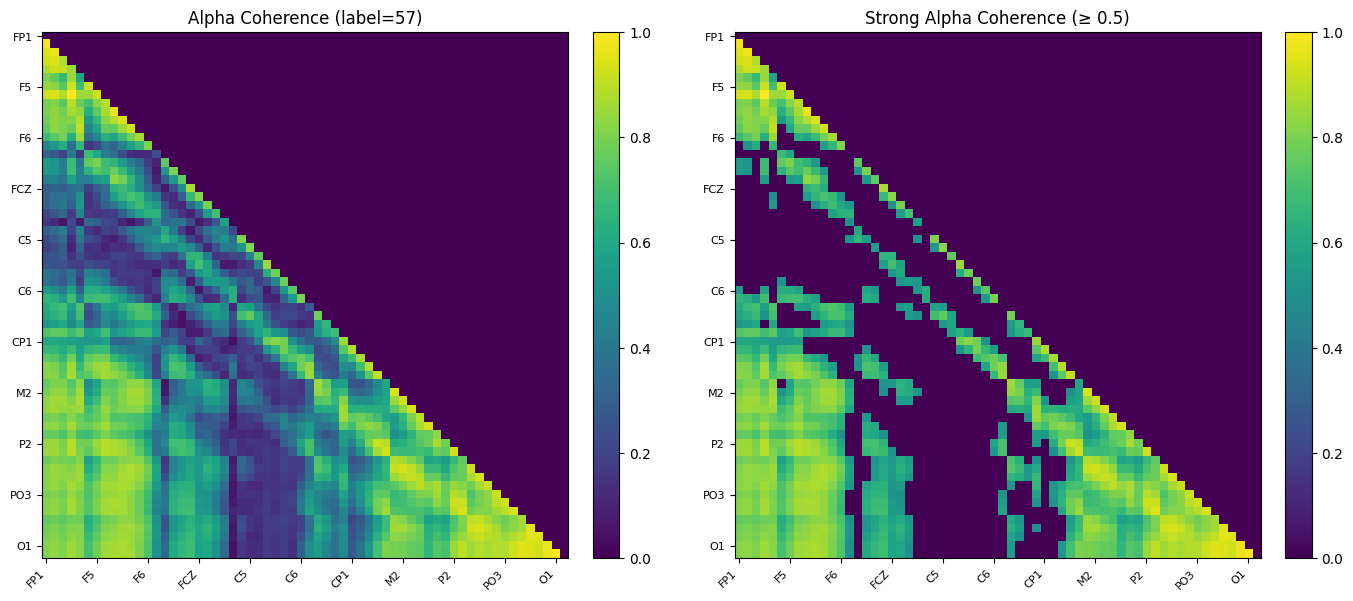

Strong coherence pairs (≥ 0.5): 523


In [ ]:
# 4) Functional connectivity using mne-connectivity
from mne_connectivity import spectral_connectivity_epochs

# Compute spectral connectivity (coherence) in alpha band
conn = spectral_connectivity_epochs(
    epochs, method="coh", fmin=8, fmax=13, faverage=True,
    verbose=False,
)
coh_matrix = conn.get_data(output="dense")[:, :, 0]  # (62, 62)

# Plot connectivity matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(coh_matrix, cmap="viridis", vmin=0, vmax=1, aspect="equal")
step = max(1, len(ch_names) // 10)
axes[0].set_xticks(range(0, len(ch_names), step))
axes[0].set_xticklabels(ch_names[::step], rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(0, len(ch_names), step))
axes[0].set_yticklabels(ch_names[::step], fontsize=8)
axes[0].set_title(f"Alpha Coherence (label={target_label})")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Thresholded
threshold = 0.5
strong = coh_matrix.copy()
strong[strong < threshold] = 0
np.fill_diagonal(strong, 0)

im2 = axes[1].imshow(strong, cmap="viridis", vmin=0, vmax=1, aspect="equal")
axes[1].set_xticks(range(0, len(ch_names), step))
axes[1].set_xticklabels(ch_names[::step], rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(0, len(ch_names), step))
axes[1].set_yticklabels(ch_names[::step], fontsize=8)
axes[1].set_title(f"Strong Alpha Coherence (≥ {threshold})")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

n_strong = np.sum(strong > 0) // 2
print(f"Strong coherence pairs (≥ {threshold}): {n_strong}")

### 5. Spatial: Topographical Maps
Voltage distribution across the scalp at different time points, using the electrode 3D positions from `montage.fif`.

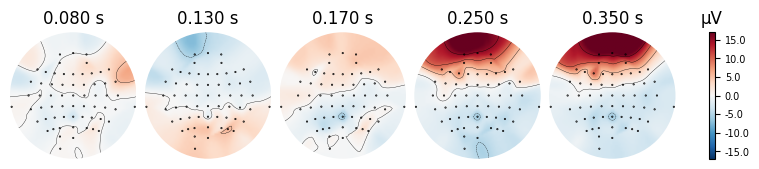

Not setting metadata
50 matching events found
No baseline correction applied
0 projection items activated


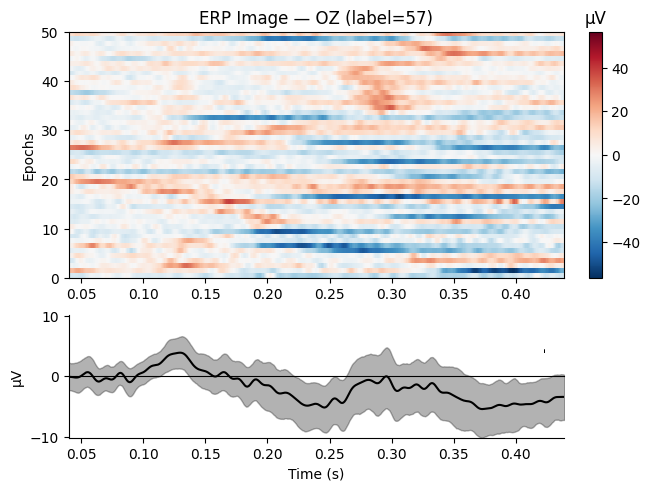

In [ ]:
# 5a) Topographical maps at key ERP time points using MNE
fig = evoked.plot_topomap(
    times=[0.08, 0.13, 0.17, 0.25, 0.35],
    ch_type="eeg",
    cmap="RdBu_r",
    contours=6,
    show=False,
)
plt.show()

# 5b) Animated-style: ERP image (trials x time) for occipital channel
fig = epochs.plot_image(
    picks=["OZ"],
    combine=None,
    show=False,
    title=f"ERP Image — OZ (label={target_label})",
)
plt.show()

### 5b. Spatial: Band Power Topographical Maps
Topographical distribution of power in each frequency band, showing which brain regions are most active at different frequencies.

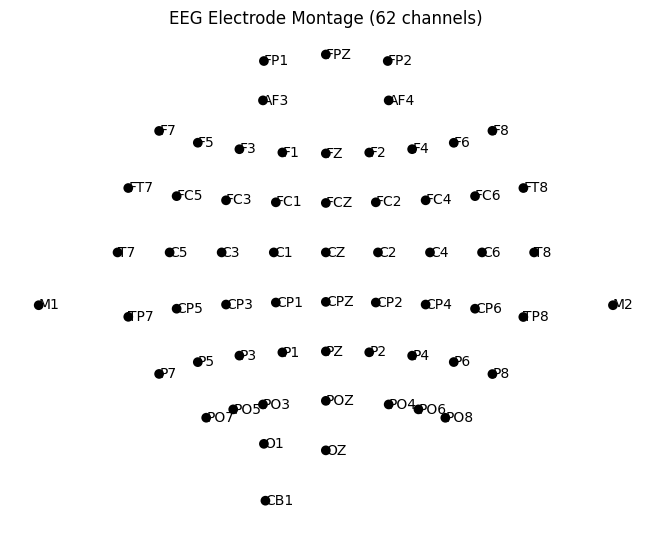

In [ ]:
# 5c) Sensor positions on the scalp
fig = epochs.plot_sensors(ch_type="eeg", show_names=True, show=False)
plt.title("EEG Electrode Montage (62 channels)")
plt.show()

### 6. 3D Field Maps
Interpolated EEG field projected onto a 3D head surface. Electrode positions come from our `data/mode/montage.fif`, while `fsaverage` provides the head surface geometry (since we don't have subject MRIs).

In [ ]:
# Electrode positions are from our montage (data/mode/montage.fif), already set on `evoked`.
# fsaverage provides only the 3D head mesh for rendering (downloaded once, ~30 MB).
fsaverage_dir = mne.datasets.fetch_fsaverage(verbose=False)
subjects_dir = fsaverage_dir.parent if hasattr(fsaverage_dir, "parent") else str(fsaverage_dir) + "/.."

# Compute field map: our electrode positions + fsaverage head surface
field_maps = mne.make_field_map(
    evoked,
    trans="fsaverage",
    subject="fsaverage",
    subjects_dir=subjects_dir,
)

# Plot 3D field map at key ERP time points
for t in [0.08, 0.17, 0.35]:
    fig = evoked.plot_field(field_maps, time=t)
    mne.viz.set_3d_title(fig, f"EEG Field Map at {int(t*1000)} ms")

Using surface from /Users/rtae/mne_data/MNE-fsaverage-data/fsaverage/bem/fsaverage-5120-5120-5120-bem.fif.
Prepare EEG mapping...
Computing dot products for 62 electrodes...
Computing dot products for 2562 surface locations...
Field mapping data ready
    Preparing the mapping matrix...
    Truncating at 3/62 components to omit less than 0.001 (0.00017)


/var/folders/53/x49yqccd0r78tkl0172f7dbr0000gn/T/ipykernel_15731/2984823209.py:7: FutureWarning: Default value for origin is "(0.0, 0.0, 0.04)" in version 1.11 but will be changed to "auto" in 1.12. Set the origin parameter explicitly to avoid this warning.
  field_maps = mne.make_field_map(


RuntimeError: Could not load any valid 3D backend
pyvistaqt: No Qt bindings could be found
notebook: No module named 'ipyevents'

 install pyvistaqt, using pip or conda:
'pip install pyvistaqt'
'conda install -c conda-forge pyvistaqt'

 or install ipywidgets, if using a notebook backend
'pip install ipywidgets'
'conda install -c conda-forge ipywidgets'